In [1]:
import pandas as pd
import numpy as np

In [48]:
class PolynomialRegression:
    def transform(self,x):
        b = None
        for i in range(self.degree):
            b = np.stack((x,x**i) , axis = 1)
            a = b.shape
            b = np.reshape(b, (a[0],a[1]*a[2]))
        x = b
        return x
    def __init__(self,optimizer = "RMSprop",degree = 3):
        self.error = None
        self._y = None
        self.b = None
        self.w = None
        self.y = None
        self.x = None
        self.w_error = None
        self.b_error = None
        self.m_w = None
        self.m_b = None
        self.v_w = None
        self.v_b = None
        self.r_v_w = None
        self.r_v_b = None
        self.hat_m_w = None
        self.hat_m_b = None
        self.epoch_count = 1
        self.epoch_limit = None
        self.hat_v_w = None
        self.hat_v_b = None
        self.update_step = lambda: None
        self.metrics = self.Metrics(self)
        self.optimiser = optimizer
        self.degree = degree
    def fit(self,xs,ys,epochs = 100,):
        self.x = xs.copy()
        self.y = ys.copy()
        self.x = self.transform(self.x)
        self.w = np.zeros(self.x.shape[1])
        self.b = 0.0
        self.v_w = np.zeros(self.x.shape[1])
        self.m_w = np.zeros(self.x.shape[1])
        self.m_b = 0
        self.v_b = 0
        self._y = np.dot(self.x , self.w) + self.b
        self.error = np.mean((self._y - self.y)**2)
        self.b_error = 2*np.mean(self._y - self.y)
        self.w_error = 2*np.dot(self.x.transpose(),self._y - self.y)/self.x.shape[0]
        self.epoch_limit = epochs
        if self.optimiser == "adam":
            update_step = self.adam
        elif self.optimiser == "RMSprop":
            update_step = self.RMSprop
        elif self.optimiser == "momentum":
            update_step = self.momentum
        elif self.optimiser == "gd":
            update_step = self.gd
        else:
            raise ValueError(f"Unknown optimizer: {self.optimiser}")
        loss = []
        while self.epoch_count <= self.epoch_limit:
            update_step(gamma = 0.0005)
            self._y = np.dot(self.x,self.w) + self.b
            self.error = np.mean((self._y - self.y)**2)
            self.b_error = 2*np.mean(self._y - self.y)
            self.w_error = 2*np.dot(self.x.transpose(),self._y - self.y)/self.x.shape[0]
            self.epoch_count += 1
            loss.append(self.error)
            print(f"Epochs {self.epoch_count -1} / {self.epoch_limit} | loss : {self.error}")
        self.metrics = self.Metrics(self)
        return loss
    def adam(self, beta1 = 0.9 , beta2 = 0.999 ,epsilon = 10**-8,gamma = 0.001):
        #momentum variables
        self.m_w = beta1*self.m_w + (1 - beta1)*self.w_error
        self.m_b = beta1*self.m_b + (1 - beta1)*self.b_error
        #RMSpropFactors
        self.v_w = beta2*self.v_w + (1-beta2)*(self.w_error**2)
        self.v_b = beta2*self.v_b + (1-beta2)*(self.b_error**2)
        #bias correcting the variance values
        self.hat_v_w = self.v_w / (1 - beta2**self.epoch_count)
        self.hat_v_b = self.v_b / (1 - beta2**self.epoch_count)
        #RMSpropFactvectors for updating the final values
        self.r_v_w = 1 / (np.sqrt(self.hat_v_w + epsilon))
        self.r_v_b = 1 / (np.sqrt(self.hat_v_b + epsilon))
        #bias correcting the momentum values
        self.hat_m_w = self.m_w / (1 - beta1**self.epoch_count)
        self.hat_m_b = self.m_b / (1 - beta1**self.epoch_count)
        #Updating the final value
        self.b = self.b - self.hat_m_b*self.r_v_b*gamma
        self.w = self.w - np.multiply(self.hat_m_w,self.r_v_w)*gamma
    def RMSprop(self,beta2 = 0.999,epsilon = 10**-8, gamma = 0.001):
        self.v_w = beta2*self.v_w + (1-beta2)*(self.w_error**2)
        self.v_b = beta2*self.v_b + (1-beta2)*(self.b_error**2)
        self.r_v_w = 1 / (np.sqrt(self.v_w + epsilon))
        self.r_v_b = 1 / (np.sqrt(self.v_b + epsilon))
        self.b = self.b - self.b_error*self.r_v_b*gamma
        self.w = self.w - np.multiply(self.w_error,self.r_v_w)*gamma
    def momentum(self,beta1 = 0.9 , gamma = 0.001):
        self.m_w = beta1*self.m_w + (1 - beta1)*self.w_error
        self.m_b = beta1*self.m_b + (1 - beta1)*self.b_error
        self.b = self.b - self.m_b*gamma
        self.w = self.w - self.m_w*gamma
    def gd(self,gamma = 2):
        self.w = self.w - gamma*self.w_error
        self.b = self.b - self.b_error*gamma
    def predict(self,x):
        x = self.transform(x)
        out = np.dot(x , self.w) + self.b
        return out
    class Metrics:
        def __init__(self,outer):
            self.parameters = None
            self.outer = outer
            self.w = self.outer.w
            self.b = self.outer.b
        def params(self):
            self.parameters = np.append(self.w , [self.b], axis = None)
            return self.parameters
        def r2_score(self, x, y):
            y_pred = self.outer.predict(x)
            ss_res = np.sum((y - y_pred) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            return 1 - (ss_res / ss_tot)
        def corr(self,x,y):
            y_pred = self.outer.predict(x)
            return np.corrcoef(y_pred,y)

In [3]:
df = pd.read_csv('poly_train.csv')

In [4]:
df.describe()


,x0,x1,x2,x3,x4,x5,x6,y
count,1179.000000,1175.000000,1170.000000,1179.000000,1188.000000,1165.000000,1177.000000,1.200000e+03
mean,25017.155313,21232.314255,-109.977187,-99.195226,504295.280504,-0.029707,-0.035565,2.769229e+40
std,14537.471043,12384.089330,109.466200,99.133969,280644.013071,0.967151,1.031233,5.802814e+40
min,105.895709,-1577.075925,-306.082987,-289.497624,10412.747734,-3.016381,-3.529210,-3.620968e+28
25%,12163.679174,10651.300361,-205.633509,-185.675060,265953.918361,-0.687808,-0.720898,1.038346e+36
50%,24747.550994,21143.517107,-104.585970,-95.115394,510816.799441,-0.052446,-0.058913,5.126653e+38
75%,37982.621159,32285.048479,-18.842327,-14.314860,731249.049779,0.607292,0.655355,2.285177e+40
max,49971.141708,43508.243909,95.360217,84.726188,999522.929079,4.025824,3.435928,3.351932e+41


In [5]:
for col in df.columns:
  df = df[df[col].isna() == False]

In [6]:
testdf = df.sample(frac = 0.1,random_state=42)
df.drop(testdf.index,inplace = True)

In [7]:
metric = pd.DataFrame({'label' : df.columns,
              'mean' : np.mean(df,axis =0),
              'std' : np.std(df,axis = 0)})

In [40]:
for col in df.columns:
    print(np.corrcoef(df[col],df['y']))

[[1.         0.67367941]
 [0.67367941 1.        ]]
[[1.         0.67849485]
 [0.67849485 1.        ]]
[[1. 1.]
 [1. 1.]]


In [9]:
df.drop(['x2','x3','x4','x5','x6'],axis = 1,inplace = True)

In [10]:
testdf.drop(['x2','x3','x4','x5','x6'],axis = 1,inplace = True)

In [8]:
metric

,label,mean,std
x0,x0,2.507311e+04,1.453734e+04
x1,x1,2.127280e+04,1.238927e+04
x2,x2,-1.082181e+02,1.092017e+02
x3,x3,-9.728118e+01,9.889548e+01
x4,x4,5.039013e+05,2.794967e+05
x5,x5,-6.095451e-03,9.537851e-01
x6,x6,-6.115359e-02,1.036637e+00
y,y,2.834241e+40,5.927164e+40


In [11]:
for col in df.columns:
  if col == "y":
      continue
  df = df[np.abs((df[col] - np.mean(df[col]))/np.std(df[col])) < 3.0]

In [12]:
for col in df.columns:

    df[col] = (df[col] - np.mean(df[col]))/np.std(df[col])

In [13]:
for col in testdf.columns:
  a = metric.loc[metric.label == col]
  testdf[col] = (testdf[col] - np.float64(a.iloc[:,1].to_numpy()))/np.float64(a.iloc[:,2].to_numpy())

C:\Users\ashis\AppData\Local\Temp\ipykernel_34772\3247371279.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  testdf[col] = (testdf[col] - np.float64(a.iloc[:,1].to_numpy()))/np.float64(a.iloc[:,2].to_numpy())


In [14]:

xs = df.drop(['y'],axis = 1)
rtarget = df.y
txs = testdf.drop(['y'],axis = 1)
target = testdf.y


In [ ]:
t

In [18]:
testdf.describe()

,x0,x1,y
count,104.000000,104.000000,104.000000
mean,-0.085775,-0.081824,-0.027201
std,1.058792,1.058685,0.937472
min,-1.687438,-1.682459,-0.478178
25%,-1.148111,-1.133568,-0.478178
50%,-0.113055,-0.041098,-0.470915
75%,0.867271,0.869423,-0.116596
max,1.709905,1.749354,4.552314


In [52]:
model = PolynomialRegression(optimizer= 'gd' , degree = 5)
loss_history = model.fit(xs.loc[:,['x0','x1']].to_numpy() , rtarget.to_numpy() , epochs = 100000)

Epochs 1 / 100000 | loss : 0.9896816732176935
Epochs 2 / 100000 | loss : 0.9796674128123377
Epochs 3 / 100000 | loss : 0.9699466105202347
Epochs 4 / 100000 | loss : 0.9605090355606526
Epochs 5 / 100000 | loss : 0.9513448211741377
Epochs 6 / 100000 | loss : 0.942444451641008
Epochs 7 / 100000 | loss : 0.9337987497629031
Epochs 8 / 100000 | loss : 0.9253988647908704
Epochs 9 / 100000 | loss : 0.9172362607840593
Epochs 10 / 100000 | loss : 0.9093027053836646
Epochs 11 / 100000 | loss : 0.9015902589873048
Epochs 12 / 100000 | loss : 0.8940912643095515
Epochs 13 / 100000 | loss : 0.8867983363148363
Epochs 14 / 100000 | loss : 0.8797043525094519
Epochs 15 / 100000 | loss : 0.8728024435798364
Epochs 16 / 100000 | loss : 0.8660859843647916
Epochs 17 / 100000 | loss : 0.859548585149719
Epochs 18 / 100000 | loss : 0.8531840832713915
Epochs 19 / 100000 | loss : 0.8469865350221801
Epochs 20 / 100000 | loss : 0.8409502078430545
Epochs 21 / 100000 | loss : 0.835069572795059
Epochs 22 / 100000 | loss

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [53]:
model.metrics.r2_score(txs.to_numpy(),target)

np.float64(0.850444910855548)

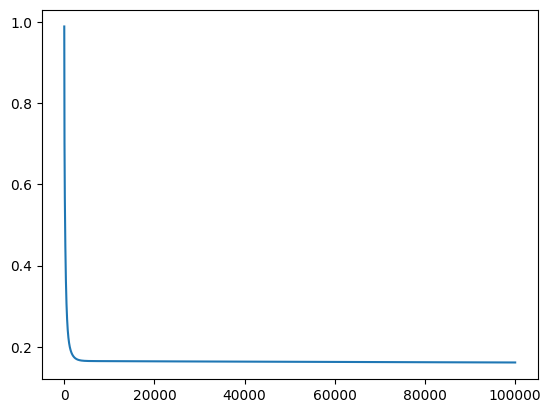

In [60]:
plt.plot(loss_history[0:100000])

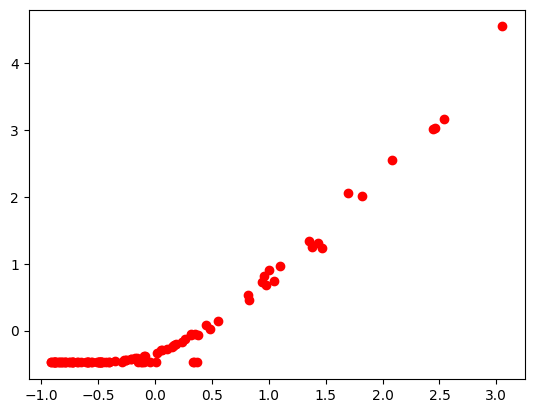

In [54]:
import matplotlib.pyplot as plt
plt.scatter(model.predict(txs.to_numpy()),target.to_numpy(),c = 'red',marker = 'o')

In [61]:
tdf = pd.read_csv('poly_test.csv')

In [62]:
tdf.describe()

,x0,x1,x2,x3,x4,x5,x6
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,23632.685318,20080.281202,-113.638826,-102.615308,483911.197304,0.056713,-0.000055
std,14442.968267,12289.302309,108.380953,97.168139,287694.116552,1.009387,1.018097
min,261.908290,-180.745470,-302.114819,-285.418974,13943.679215,-3.887804,-3.444584
25%,10935.068058,8916.315430,-212.926172,-188.006478,225929.249063,-0.569714,-0.625047
50%,22455.437103,19011.758076,-111.367933,-102.300403,462079.882556,0.036904,0.017785
75%,36132.621299,30562.043798,-21.778446,-22.977799,739814.272092,0.778196,0.617868
max,49877.055487,44206.419101,81.246099,88.041572,995561.212543,2.629237,3.100647


In [63]:
tdf.size

2800

In [64]:
tdf.shape

(400, 7)

In [65]:
tdf.drop(['x2','x3','x4','x5','x6'],axis = 1,inplace = True)

In [67]:
for col in ['x0','x1']:
  a = metric.loc[metric.label == col]
  tdf[col] = (tdf[col] - np.float64(a.iloc[:,1].to_numpy()))/np.float64(a.iloc[:,2].to_numpy())

C:\Users\ashis\AppData\Local\Temp\ipykernel_34772\3287966733.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  tdf[col] = (tdf[col] - np.float64(a.iloc[:,1].to_numpy()))/np.float64(a.iloc[:,2].to_numpy())


In [69]:
pred = model.predict(tdf.to_numpy())*np.float64(metric.loc[metric.label == 'y'].iloc[:,2]) + np.float64(metric.loc[metric.label == 'y'].iloc[:,1])

C:\Users\ashis\AppData\Local\Temp\ipykernel_34772\2012411245.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = model.predict(tdf.to_numpy())*np.float64(metric.loc[metric.label == 'y'].iloc[:,2]) + np.float64(metric.loc[metric.label == 'y'].iloc[:,1])


In [71]:
preddf = pd.DataFrame({'prediction' : pred},dtype= np.float64)

In [72]:
preddf.isna().value_counts()

prediction
False         400
Name: count, dtype: int64

In [73]:
preddf.to_csv('pred_poly.csv')